# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 1.5486$
  - $\Omega_R/E_r = 1.0585$
  - $\gamma/E_r \sim 0.2$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

from ybsoc import *

In [2]:
system_rabi = YbSOC2bodyLoss(
    d=jnp.pi / 3,
    lengths=[12,],
    n_particle=4,
    hbar=1.,
    q=0.,
    m_Yb=1.,
    delta=1.5486,
    omega_R=1.0585,
    gamma=0.,
    array_type='numpy'
)

hamiltonian_rabi = system_rabi.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:01<00:00, 7006.59it/s]


In [3]:
eigenvalues_rabi, eigenvectors_rabi = np.linalg.eigh(hamiltonian_rabi)

In [4]:
system_loss = YbSOC2bodyLoss(
    d=jnp.pi / 3,
    lengths=[12,],
    n_particle=4,
    hbar=1.,
    q=0,
    m_Yb=1.,
    delta=0.,
    omega_R=0.,
    gamma=0.2,
    array_type='numpy'
)

hamiltonian_loss = system_loss.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:02<00:00, 4760.20it/s]


In [5]:
eigenvalues_loss, eigenvectors_loss = np.linalg.eig(hamiltonian_loss)

In [6]:
initial_state = system_rabi.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), 1),
        ((2,), 1),
        ((11,), 1),
    )
)

In [7]:
psi_tilde = np.linalg.solve(eigenvectors_rabi, initial_state)

t0 = 0
t1 = 0.8 / 0.1129
save_at = np.linspace(t0, t1, 201)
step_size = save_at[1] - save_at[0]

evolution_rabi = np.exp(-1j * eigenvalues_rabi * step_size / system_rabi.hbar)
spin_up_numbers = np.zeros((len(save_at),), dtype=np.float64)
spin_down_numbers = np.zeros((len(save_at),), dtype=np.float64)
remaining_fraction = np.zeros((len(save_at),), dtype=np.float64)

loss_time = 2.0 / 0.1129
evolution_loss = np.exp(-1j * eigenvalues_loss * step_size)

for i in tqdm.trange(len(save_at)):
    psi = np.einsum('ij,j->i', eigenvectors_rabi, psi_tilde)
    
    n_up, n_down = system_rabi.momentum_sp_expected_numbers(psi)
    spin_up_numbers[i] = np.sum(n_up) / system_loss.n_particle
    spin_down_numbers[i] = np.sum(n_down) / system_loss.n_particle
        
    n_up, n_down = system_loss.momentum_sp_expected_numbers(
        np.einsum('ij,j->i', eigenvectors_loss, evolution_loss * np.linalg.solve(eigenvectors_loss, psi))
    )
    remaining_fraction[i] = np.sum(n_up + n_down) / system_loss.n_particle
    psi_tilde = evolution_rabi * psi_tilde 

100%|██████████| 201/201 [53:31<00:00, 15.98s/it]


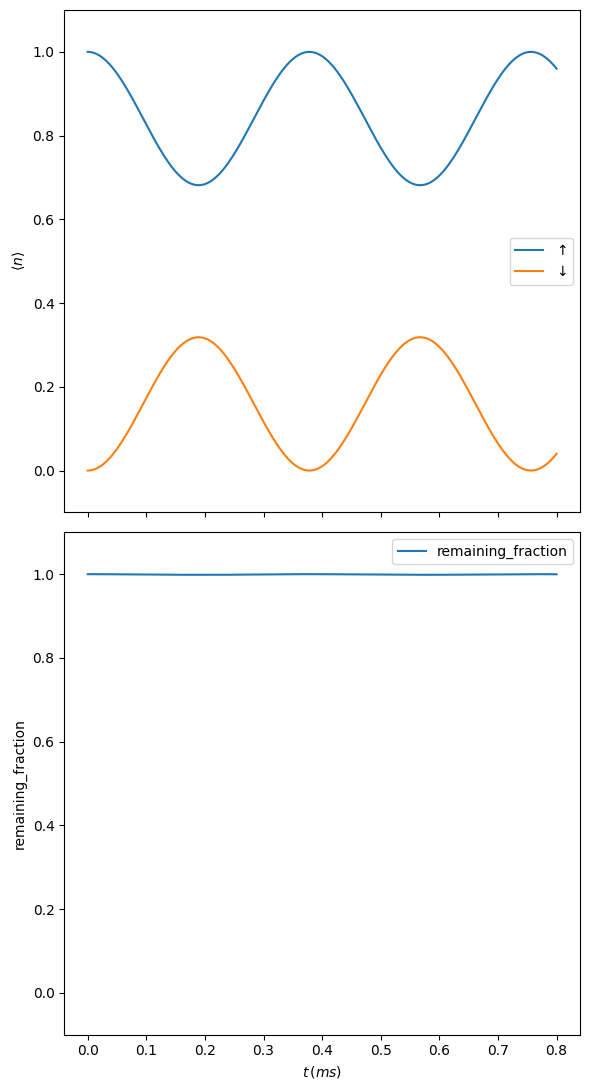

In [ ]:
# 시간 축 계산
t = save_at * 0.1129

# 위·아래 두 개의 subplot 생성, 가로축 공유
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 11))

# 첫 번째 축: spin up/down
ax1.plot(t, spin_up_numbers,   label="$\\uparrow$")
ax1.plot(t, spin_down_numbers, label="$\\downarrow$")
ax1.set_ylabel("$\\langle n \\rangle$")
ax1.set_ylim(-0.1, 1.1)
ax1.legend()

# 두 번째 축: remaining_fraction
ax2.plot(t, remaining_fraction, label="remaining_fraction")
ax2.set_ylabel("remaining_fraction")
ax2.set_xlabel("$t\\,(ms)$")
ax2.set_ylim(-0.1, 1.1)
ax2.legend()

# 레이아웃 자동 조정
plt.tight_layout()
plt.show()
